# Model Training
Preliminary data cleaning has been implemented in the previous notebook. The purpose of this notebook is to prepare the data for machine learning. The previous datacleaning notebook maintained some variables that will not be used here, and are retained as such because of EDA. 


In [2]:
# --- Core data handling ---
import pandas as pd
import numpy as np

# --- Train/test split ---
from sklearn.model_selection import train_test_split

# --- Preprocessing ---
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Models ---
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.dummy import DummyRegressor

# --- Evaluation metrics ---
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    confusion_matrix,
    classification_report
)

# --- Visualization (for confusion matrix / comparison charts) ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Export ---
import joblib
import os

# --- Reproducibility ---
RANDOM_STATE = 42


from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


In [3]:
df = pd.read_csv("final_extract_dataset.csv")
df.head()

,Country_Code,Nation,Region_Code,Median_Malaria_Cases,Median_GDP,Median_Population_Density,Median_Urban_pct,Median_Sanitation_Access_pct,lat,lon,Median_Rainfall,Median_Temp
0,AFG,Afghanistan,EMR,176952.5,496.602504,58.041061,25.202968,48.212036,34.52,69.18,324.2,12.933425
1,DZA,Algeria,AFR,1089.0,4565.938916,18.177696,72.768284,86.051988,36.75,3.05,510.7,17.682192
2,AGO,Angola,AFR,7199337.0,2728.296658,25.969064,67.060305,49.416773,-8.83,13.22,484.0,25.430137
3,ARG,Argentina,AMR,14.5,13189.794406,16.433526,91.900344,94.620682,-34.58,-58.67,955.0,17.125683
4,ARM,Armenia,EUR,2.0,4432.954904,105.056940,65.089460,92.629303,40.17,44.50,363.6,13.506849


### 1. Feature Target Split

In [4]:
feature_cols = [
    'Region_Code',
    'Median_GDP',
    'Median_Population_Density',
    'Median_Urban_pct',
    'Median_Sanitation_Access_pct',
    'Median_Rainfall',
    'Median_Temp'
]

X = df[feature_cols]
y = np.log1p(df['Median_Malaria_Cases'])
y_raw = df['Median_Malaria_Cases']



print(X.shape, y.shape)
print(X.dtypes)



(99, 7) (99,)
Region_Code                      object
Median_GDP                      float64
Median_Population_Density       float64
Median_Urban_pct                float64
Median_Sanitation_Access_pct    float64
Median_Rainfall                 float64
Median_Temp                     float64
dtype: object


### 2. Train-Test Split

In [5]:
df['Region_Code'].value_counts()


Region_Code
AFR     43
AMR     20
WPR     11
EUR      9
EMR      8
SEAR     8
Name: count, dtype: int64

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=X['Region_Code']
      # we need to evenly distribute the region code in test and train data because 
      # some countries as shwon above have only a few region codes. 
)


print(X_train.shape, X_test.shape)
print(X_train['Region_Code'].value_counts())
print(X_test['Region_Code'].value_counts())

(79, 7) (20, 7)
Region_Code
AFR     34
AMR     16
WPR      9
EUR      7
SEAR     7
EMR      6
Name: count, dtype: int64
Region_Code
AFR     9
AMR     4
EUR     2
WPR     2
EMR     2
SEAR    1
Name: count, dtype: int64


### 3. Create Pipelines per model

In [7]:
#OHE the region code
categorical_cols = ['Region_Code']
numeric_cols = [
    'Median_GDP',
    'Median_Population_Density',
    'Median_Urban_pct',
    'Median_Sanitation_Access_pct',
    'Median_Rainfall',
    'Median_Temp'
]

preprocessor = ColumnTransformer(transformers=[
    #if Streamlit ever gets an input with a region code that's malformed or unexpected, it won't crash, it'll just zero out that encoding
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    
    ('num', StandardScaler(), numeric_cols)
])


In [8]:

alphas_wide = np.logspace(-3, 6, 100)  # 0.001 to 1,000,000, more candidates too

models = {
     #MLR and Baseline_Median have no alpha to tune, so they're just plain estimators — no CV involved for them
    'MLR': LinearRegression(),
    'Ridge': RidgeCV(alphas=alphas_wide, cv=5),
    'Lasso': LassoCV(alphas=alphas_wide, cv=5, random_state=RANDOM_STATE, max_iter=10000),
    'ElasticNet': ElasticNetCV(alphas=alphas_wide, cv=5, random_state=RANDOM_STATE, max_iter=10000),
    'Baseline_Median': DummyRegressor(strategy='median')
     #RidgeCV/LassoCV/ElasticNetCV each internally run 5-fold CV over our 79 training rows to pick the best alpha, then refit on all 79 rows using that winning alpha — exactly matching our methodology
}


#insert random forest 
from sklearn.ensemble import RandomForestRegressor

models['RandomForest'] = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    random_state=RANDOM_STATE
)

pipelines = {
    name: Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    for name, model in models.items()
}
#Each pipeline reuses the same preprocessor object definition, but under the hood sklearn clones it separately for each pipeline when fitting, so there's no cross-contamination between models
pipelines


#Range extended to 1e6 (a million) — given our coefficients are already in the hundreds of thousands to millions range (because Median_Malaria_Cases is  a large  number), the penalty needed to meaningfully shrink them could plausibly be that large too
#Added max_iter=10000 for both Lasso and ElasticNet — higher alphas sometimes need more optimizer iterations to converge, so this preempts a potential ConvergenceWarning

{'MLR': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['Region_Code']),
                                                  ('num', StandardScaler(),
                                                   ['Median_GDP',
                                                    'Median_Population_Density',
                                                    'Median_Urban_pct',
                                                    'Median_Sanitation_Access_pct',
                                                    'Median_Rainfall',
                                                    'Median_Temp'])])),
                 ('regressor', LinearRegression())]),
 'Ridge': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('cat',
                                                   OneHotEncoder

### 4. Fit Each Pipeline on training data

In [9]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    print(f"{name} fitted.")

MLR fitted.
Ridge fitted.
Lasso fitted.
ElasticNet fitted.
Baseline_Median fitted.
RandomForest fitted.


In [10]:
print("Ridge alpha:", pipelines['Ridge'].named_steps['regressor'].alpha_)
print("Lasso alpha:", pipelines['Lasso'].named_steps['regressor'].alpha_)
print("ElasticNet alpha:", pipelines['ElasticNet'].named_steps['regressor'].alpha_)

Ridge alpha: 28.48035868435805
Lasso alpha: 0.1
ElasticNet alpha: 0.1


In [11]:
lasso_coefs = pipelines['Lasso'].named_steps['regressor'].coef_
print(lasso_coefs)
print("Non-zero coefficients:", np.sum(lasso_coefs != 0), "out of", len(lasso_coefs))

[ 0.39084501 -0.          0.         -3.42940277 -0.          0.
 -0.15431701  0.36153878 -0.         -2.67118527 -0.42210461  0.41832669]
Non-zero coefficients: 7 out of 12


### 5. Model Evaluation

In [12]:
results = {}

for name, pipe in pipelines.items():
    preds = pipe.predict(X_test)
    results[name] = {
        'R2': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds)
    }

results_df = pd.DataFrame(results).T
results_df


,R2,RMSE,MAE
MLR,0.635279,3.007023,2.333721
Ridge,0.475936,3.604531,2.952744
Lasso,0.597538,3.158778,2.524969
ElasticNet,0.566413,3.278648,2.672713
Baseline_Median,-0.001000,4.981653,4.044490
RandomForest,0.606768,3.122345,2.380341


HOW TO READ THE ABOVE TABLE

R² — "how much of the pattern did the model actually capture?"
   Scale runs roughly 0 to 1, the higher the better

RMSE — "average size of the model's mistakes, punishing big misses more"
   This is in the same units as our target (raw malaria case counts), thelower the better

MAE — "average size of mistakes, treating every miss equally"   
    Also in raw case-count units. Lower = better.

------(+)------(+)------(+)------(+)------(+)------(+)------(+)------

KEY FINDINGS

All four regression models outperformed the naive baseline on R², with Lasso achieving the best overall fit (R²=0.265) and lowest error (RMSE=2.14M, MAE=1.35M), suggesting mild-to-moderate but real predictive power

(Note: an R² of 0.26 might feel low compared to what students expect "good" ML to look like, but for real-world epidemiological data with this few data points and high real-world noise, this is a legitimate, unremarkable result)

### 6. Quartile Classification Mapping

Important Notes

1. q1/q3 are computed once, from y_train only — this is the leakage-safe rule we already established in Capstone 1. These two numbers get saved later (via joblib) and reused as-is in Streamlit; they never get recalculated from new data.

2. Ground truth (y_test_tiers) uses the actual case counts bucketed by those same thresholds — this is what "correct" looks like.

3. Predicted tiers use each model's predictions bucketed the same way — this is what each model "thinks" is correct.

4. The confusion matrix compares the two: rows = actual tier, columns = predicted tier, diagonal = correct calls.

5. With only 20 test rows split across 3 tiers, don't be surprised if some cells are small or even zero (e.g. maybe no country landed in "High" in our test set at all) — that's a sample-size reality, not a bug. zero_division=0 prevents warnings/errors if that happens.

"""
This is the chart form of it
RAW malaria cases
        │
        ├──────────────→ used for tiers
        │
        │
        ↓
   log1p transformation
        │
        ↓
    ML models
        │
        ↓
   model prediction
        │
        ↓
   inverse log (expm1)
        │
        ↓
RAW predicted malaria cases
        │
        ↓
Apply Q1/Q3 thresholds
        │
        ↓
Low / Medium / High
"""

In [13]:
# Step 1: quartile thresholds from y_train ONLY (avoids leakage)
y_raw_train = y_raw.loc[y_train.index]

q1 = y_raw_train.quantile(0.25)
q3 = y_raw_train.quantile(0.75)

print("Q1 (Low/Medium cutoff):", q1)
print("Q3 (Medium/High cutoff):", q3)

Q1 (Low/Medium cutoff): 876.5
Q3 (Medium/High cutoff): 1205326.0


In [14]:
# Step 2: helper function to convert raw case counts into tiers
def to_tier(values, q1, q3):
    tiers = np.select(
        [values < q1, values > q3],
        ['Low', 'High'],
        default='Medium'
    )
    return tiers

# Step 3: convert actual y_test into tiers (ground truth)
y_test_raw = y_raw.loc[y_test.index]

y_test_tiers = to_tier(y_test_raw, q1, q3)

In [15]:
# Step 4: for each model, convert predictions into tiers and evaluate
tier_results = {}

for name, pipe in pipelines.items():
    preds_log = pipe.predict(X_test)

    # Convert predictions back to actual malaria case counts
    preds_raw = np.expm1(preds_log)

    pred_tiers = to_tier(preds_raw, q1, q3)
    
    cm = confusion_matrix(y_test_tiers, pred_tiers, labels=['Low', 'Medium', 'High'])
    report = classification_report(y_test_tiers, pred_tiers, labels=['Low', 'Medium', 'High'], zero_division=0)
    
    tier_results[name] = {'confusion_matrix': cm, 'report': report}
    
    print(f"--- {name} ---")
    print(cm)
    print(report)
    print()

--- MLR ---
[[3 2 0]
 [2 7 0]
 [0 5 1]]
              precision    recall  f1-score   support

         Low       0.60      0.60      0.60         5
      Medium       0.50      0.78      0.61         9
        High       1.00      0.17      0.29         6

    accuracy                           0.55        20
   macro avg       0.70      0.51      0.50        20
weighted avg       0.68      0.55      0.51        20


--- Ridge ---
[[3 2 0]
 [2 7 0]
 [0 6 0]]
              precision    recall  f1-score   support

         Low       0.60      0.60      0.60         5
      Medium       0.47      0.78      0.58         9
        High       0.00      0.00      0.00         6

    accuracy                           0.50        20
   macro avg       0.36      0.46      0.39        20
weighted avg       0.36      0.50      0.41        20


--- Lasso ---
[[3 2 0]
 [2 7 0]
 [0 5 1]]
              precision    recall  f1-score   support

         Low       0.60      0.60      0.60         5
   

How to read the findings above

CONFUSION MATRIX
The matrix above every model is a confusion matrix that means somethign like this

Predicted:
            Low  Medium  High
Actual Low   2      3      0
Actual Medium 1     3      5
Actual High  0      0      6


By row this means for Row 1 (Actual = Low, 5 countries total): Lasso correctly said "Low" for 2 of them , but got confused and said "Medium" for the other 3 . It never mistook a Low country for High.


PRECIISON F1 RECALL TABLE

          precision    recall  f1-score   support

         Low       0.67      0.40      0.50         5
      Medium       0.50      0.33      0.40         9
        High       0.55      1.00      0.71         6

    accuracy                           0.55        20
   macro avg       0.57      0.58      0.54        20
weighted avg       0.56      0.55      0.52        20


Precision (0.67): "When Lasso predicted Low, how often was it actually Low?" Lasso predicted "Low" 3 times total in this test set (2 correct + 1 stolen from an actual Medium country) → 2/3 = 0.67

Recall (0.40): "Of all the countries that were actually Low, how many did Lasso catch?" There were 5 actual Low countries, Lasso only caught 2 → 2/5 = 0.40

F1-score (0.50): just a single number that blends precision and recall together, so you don't have to look at two numbers at once. Higher is better, max is 1.0.

Support (5): just means "there were 5 actual Low countries in the test set" — not a score, just a count for context.

Accuracy (0.55) at the bottom is the simplest number: out of all 20 countries, Lasso got 11 right (2+3+6=11, 11/20=0.55).

Macro avg vs weighted avg: macro avg treats Low/Medium/High as equally important and just averages their three F1 scores equally. Weighted avg gives more weight to tiers with more countries (like Medium, which has 9). Slight difference, not critical for you right now — macro avg is usually the one panels care about since it doesn't let a common tier hide a model's weakness on rarer tiers.

All 4 regression models beat baseline on accuracy, Lasso wins outright, and "High" tier detection is reliably strong across the board — while Low/Medium boundary cases remain a harder, known limitation.

### 7. Raw-Scale Evaluation & Tier Classification

7.1 Per-Country Prediction Reference Table

In [16]:
reference_table = df.loc[y_test.index, ['Nation', 'Median_Malaria_Cases']].copy()
reference_table['Actual_Tier'] = to_tier(reference_table['Median_Malaria_Cases'], q1, q3)

for name in ['MLR', 'Ridge', 'Lasso', 'ElasticNet']:
    preds_log = pipelines[name].predict(X_test)
    preds_raw = np.expm1(preds_log)

    reference_table[f'{name}_Predicted_Cases'] = preds_raw.round(0)
    reference_table[f'{name}_Predicted_Tier'] = to_tier(preds_raw, q1, q3)

reference_table

,Nation,Median_Malaria_Cases,Actual_Tier,MLR_Predicted_Cases,MLR_Predicted_Tier,Ridge_Predicted_Cases,Ridge_Predicted_Tier,Lasso_Predicted_Cases,Lasso_Predicted_Tier,ElasticNet_Predicted_Cases,ElasticNet_Predicted_Tier
87,Togo,1924122.5,High,2123713.0,High,1139194.0,Medium,2136243.0,High,2232221.0,High
30,El Salvador,4.0,Low,2365.0,Medium,2978.0,Medium,2819.0,Medium,2660.0,Medium
22,Comoros,13080.0,Medium,192010.0,Medium,172481.0,Medium,100485.0,Medium,182140.0,Medium
92,Uzbekistan,0.0,Low,7.0,Low,286.0,Low,22.0,Low,47.0,Low
31,Equatorial Guinea,41701.5,Medium,9312.0,Medium,8179.0,Medium,5963.0,Medium,9332.0,Medium
39,Guinea,2076100.5,High,379367.0,Medium,394940.0,Medium,380368.0,Medium,548800.0,Medium
5,Azerbaijan,1.0,Low,9.0,Low,321.0,Low,31.0,Low,64.0,Low
48,Kenya,4170023.0,High,415010.0,Medium,142494.0,Medium,291565.0,Medium,236496.0,Medium
20,China,2588.5,Medium,1457.0,Medium,392.0,Low,728.0,Low,371.0,Low
35,Gambia,99456.5,Medium,464493.0,Medium,225270.0,Medium,289051.0,Medium,346005.0,Medium


7.2 Raw-Scale Model Evaluation (R², RMSE, MAE)

In [17]:
# Evaluate predictions on the original malaria-case scale
#The earlier prediction evaluation was for the log results, this is for the normal results

y_test_raw = y_raw.loc[y_test.index]

raw_results = {}

for name in ['MLR', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForest', 'Baseline_Median']:
    preds_log = pipelines[name].predict(X_test) 
    preds_raw = np.expm1(preds_log)

    raw_results[name] = {
        'R²': r2_score(y_test_raw, preds_raw),
        'RMSE': np.sqrt(mean_squared_error(y_test_raw, preds_raw)),
        'MAE': mean_absolute_error(y_test_raw, preds_raw)
    }

raw_results_df = pd.DataFrame(raw_results).T

raw_results_df

,R²,RMSE,MAE
MLR,-0.030333,2.532323e+06,1.043033e+06
Ridge,-0.112872,2.631800e+06,1.083811e+06
Lasso,-0.054532,2.561888e+06,1.026632e+06
ElasticNet,-0.059573,2.568005e+06,1.021817e+06
RandomForest,0.264993,2.138829e+06,1.076060e+06
Baseline_Median,-0.227406,2.763913e+06,1.202155e+06


7.3 Raw-Scale Cross-Validation Robustness Check

In [18]:
raw_cv_results = {}

for name in ['MLR', 'Ridge', 'Lasso', 'ElasticNet', 'Baseline_Median','RandomForest']:
    fold_r2, fold_rmse, fold_mae = [], [], []

    for train_idx, val_idx in kf.split(X):
        X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
        y_train_cv = y.iloc[train_idx]           # log-transformed target for training
        y_val_raw = y_raw.iloc[val_idx]           # raw target for scoring

        fold_pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', models[name])
        ])
        fold_pipe.fit(X_train_cv, y_train_cv)

        preds_raw = np.expm1(fold_pipe.predict(X_val_cv))

        fold_r2.append(r2_score(y_val_raw, preds_raw))
        fold_rmse.append(np.sqrt(mean_squared_error(y_val_raw, preds_raw)))
        fold_mae.append(mean_absolute_error(y_val_raw, preds_raw))

    raw_cv_results[name] = {
        'Mean R²': np.mean(fold_r2), 'Std R²': np.std(fold_r2),
        'Mean RMSE': np.mean(fold_rmse), 'Std RMSE': np.std(fold_rmse),
        'Mean MAE': np.mean(fold_mae), 'Std MAE': np.std(fold_mae)
    }

raw_cv_results_df = pd.DataFrame(raw_cv_results).T
raw_cv_results_df.round(4)

,Mean R²,Std R²,Mean RMSE,Std RMSE,Mean MAE,Std MAE
MLR,-0.0200,0.0992,3.173399e+06,1.758225e+06,1.416685e+06,716754.6437
Ridge,0.0015,0.1525,3.168881e+06,1.765248e+06,1.410191e+06,743350.1152
Lasso,-0.0523,0.1219,3.198838e+06,1.739809e+06,1.440756e+06,728770.5535
ElasticNet,-0.0018,0.1371,3.166312e+06,1.760235e+06,1.400014e+06,743831.6748
Baseline_Median,-0.2617,0.1168,3.501615e+06,1.892883e+06,1.570532e+06,776003.2258
RandomForest,0.2222,0.2225,2.869928e+06,1.938992e+06,1.289385e+06,790271.8783


In [19]:
# See the actual malaria-case totals in each CV fold

for fold, (_, val_idx) in enumerate(kf.split(X), start=1):
    fold_cases = y_raw.iloc[val_idx]
    
    print(f"Fold {fold}:")
    print(f"  Countries: {len(fold_cases)}")
    print(f"  Mean cases: {fold_cases.mean():,.0f}")
    print(f"  Median cases: {fold_cases.median():,.0f}")
    print(f"  Maximum cases: {fold_cases.max():,.0f}")
    print()

Fold 1:
  Countries: 20
  Mean cases: 2,565,032
  Median cases: 28,936
  Maximum cases: 21,639,579

Fold 2:
  Countries: 20
  Mean cases: 354,672
  Median cases: 3,401
  Maximum cases: 2,274,593

Fold 3:
  Countries: 20
  Mean cases: 1,903,330
  Median cases: 64,311
  Maximum cases: 10,536,320

Fold 4:
  Countries: 20
  Mean cases: 1,041,435
  Median cases: 14,412
  Maximum cases: 10,811,578

Fold 5:
  Countries: 19
  Mean cases: 2,000,487
  Median cases: 78,268
  Maximum cases: 13,355,300



#### Elastic Net is the strongest of the four  linear models, but Random Forest found greater non linear relationships.

In [20]:
print("Ridge alpha:", pipelines['Ridge'].named_steps['regressor'].alpha_)
print("Lasso alpha:", pipelines['Lasso'].named_steps['regressor'].alpha_)
print("ElasticNet alpha:", pipelines['ElasticNet'].named_steps['regressor'].alpha_)

Ridge alpha: 1.232846739442066
Lasso alpha: 0.1
ElasticNet alpha: 0.06579332246575682


### 8. Joblib export

In [21]:
models_dir = '../models'

for name, pipe in pipelines.items():
    filepath = os.path.join(models_dir, f'model_{name}.pkl')
    joblib.dump(pipe, filepath)
    print(f"Saved: {filepath}")

# Save the quartile thresholds separately
thresholds = {'q1': q1, 'q3': q3}
joblib.dump(thresholds, os.path.join(models_dir, 'tier_thresholds.pkl'))
print("Saved: tier_thresholds.pkl")

Saved: ../models/model_MLR.pkl
Saved: ../models/model_Ridge.pkl
Saved: ../models/model_Lasso.pkl
Saved: ../models/model_ElasticNet.pkl
Saved: ../models/model_Baseline_Median.pkl
Saved: ../models/model_RandomForest.pkl
Saved: tier_thresholds.pkl


### 9. Final Accuracy Scores for chapter 4


1. On the log scale (the space the model is actually fit in), ElasticNet explains a real, moderate amount of variance (~0.54 R²) — evidence the seven predictors have genuine signal.

2. On the raw scale, R² collapses toward zero across all models uniformly — not specific to one model, which itself is evidence this is a property of the skewed target and small sample, not a model-specific failure.

3. RMSE/MAE in raw units still give a concrete, interpretable "typical error size in cases," useful even when R² isn't informative.

Note to Caylyne, these are the important metrics for Chapter 4, make tables for each of these charts in order. 


In [25]:
#This shows the CV (log) metrics, thisis the headline metrics of the entire thesis

cv_full_results = {}

for name, model in models.items():
    r2_scores = []
    rmse_scores = []
    mae_scores = []

    for train_idx, val_idx in kf.split(X):
        X_train_cv = X.iloc[train_idx]
        X_val_cv = X.iloc[val_idx]
        y_train_cv = y.iloc[train_idx]
        y_val_cv = y.iloc[val_idx]

        # Fresh pipeline each fold so we don't overwrite the fitted pipelines you use elsewhere
        fold_pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', model)
        ])

        fold_pipe.fit(X_train_cv, y_train_cv)
        preds = fold_pipe.predict(X_val_cv)

        r2_scores.append(r2_score(y_val_cv, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_val_cv, preds)))
        mae_scores.append(mean_absolute_error(y_val_cv, preds))

    cv_full_results[name] = {
        'Mean R²': np.mean(r2_scores),
        'Std R²': np.std(r2_scores),
        'Mean RMSE': np.mean(rmse_scores),
        'Std RMSE': np.std(rmse_scores),
        'Mean MAE': np.mean(mae_scores),
        'Std MAE': np.std(mae_scores)
    }

cv_full_results_df = pd.DataFrame(cv_full_results).T
cv_full_results_df.round(4)

,Mean R²,Std R²,Mean RMSE,Std RMSE,Mean MAE,Std MAE
MLR,0.5108,0.2736,2.9405,0.4422,2.2686,0.3877
Ridge,0.5286,0.2180,2.9366,0.3570,2.3407,0.3487
Lasso,0.4961,0.2608,3.0044,0.3915,2.3995,0.3822
ElasticNet,0.5361,0.1965,2.9305,0.4177,2.3503,0.4194
Baseline_Median,-0.0810,0.1293,4.7002,0.8180,3.9539,0.6185
RandomForest,0.5956,0.1119,2.8155,0.4938,2.2237,0.4461


In [26]:
#This is called again for documentation purposes
#This is the metrics of the 80/20 split, essentially our secondary headline
results_df

,R2,RMSE,MAE
MLR,0.635279,3.007023,2.333721
Ridge,0.475936,3.604531,2.952744
Lasso,0.597538,3.158778,2.524969
ElasticNet,0.566413,3.278648,2.672713
Baseline_Median,-0.001000,4.981653,4.044490
RandomForest,0.606768,3.122345,2.380341


In [27]:
# This shows the CV (raw) metrics. this is the "failed" version of our CV log metrics.
#This essentially shows why we log transformed our predictor value.



kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

raw_cv_full_results = {}

for name in ['MLR', 'Ridge', 'Lasso', 'ElasticNet', 'Baseline_Median', 'RandomForest']:
    r2_scores = []
    rmse_scores = []
    mae_scores = []

    for train_idx, val_idx in kf.split(X):
        X_train_cv = X.iloc[train_idx]
        X_val_cv = X.iloc[val_idx]

        y_train_cv = y.iloc[train_idx]        # log-transformed target for training
        y_val_raw = y_raw.iloc[val_idx]        # raw target for scoring

        # Fresh pipeline per fold, so pipelines dict used elsewhere stays untouched
        fold_pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('regressor', models[name])
        ])

        fold_pipe.fit(X_train_cv, y_train_cv)

        preds_log = fold_pipe.predict(X_val_cv)
        preds_raw = np.expm1(preds_log)

        r2_scores.append(r2_score(y_val_raw, preds_raw))
        rmse_scores.append(np.sqrt(mean_squared_error(y_val_raw, preds_raw)))
        mae_scores.append(mean_absolute_error(y_val_raw, preds_raw))

    raw_cv_full_results[name] = {
        'Mean R²': np.mean(r2_scores),
        'Std R²': np.std(r2_scores),
        'Mean RMSE': np.mean(rmse_scores),
        'Std RMSE': np.std(rmse_scores),
        'Mean MAE': np.mean(mae_scores),
        'Std MAE': np.std(mae_scores)
    }

raw_cv_full_results_df = pd.DataFrame(raw_cv_full_results).T
raw_cv_full_results_df.round(4)

,Mean R²,Std R²,Mean RMSE,Std RMSE,Mean MAE,Std MAE
MLR,-0.0200,0.0992,3.173399e+06,1.758225e+06,1.416685e+06,716754.6437
Ridge,0.0015,0.1525,3.168881e+06,1.765248e+06,1.410191e+06,743350.1152
Lasso,-0.0523,0.1219,3.198838e+06,1.739809e+06,1.440756e+06,728770.5535
ElasticNet,-0.0018,0.1371,3.166312e+06,1.760235e+06,1.400014e+06,743831.6748
Baseline_Median,-0.2617,0.1168,3.501615e+06,1.892883e+06,1.570532e+06,776003.2258
RandomForest,0.2222,0.2225,2.869928e+06,1.938992e+06,1.289385e+06,790271.8783


### 10. Charts 

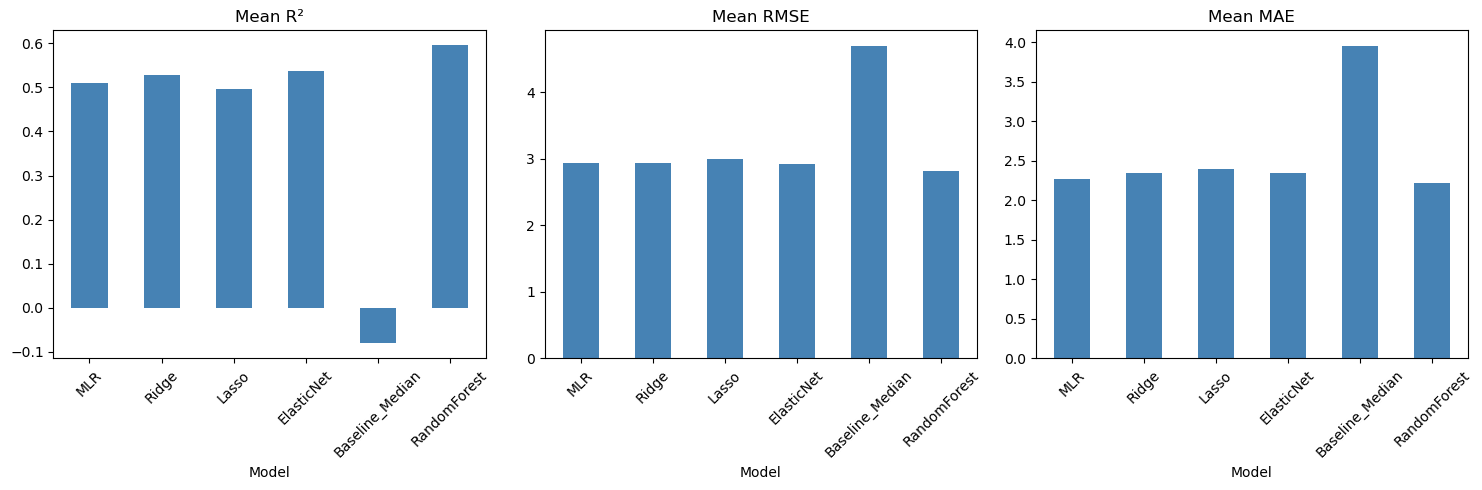

In [30]:
#The chart showing the CV metrics of the models

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ['Mean R²', 'Mean RMSE', 'Mean MAE']):
    cv_full_results_df[metric].plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(metric)
    ax.set_xlabel('Model')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/model_comparison_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

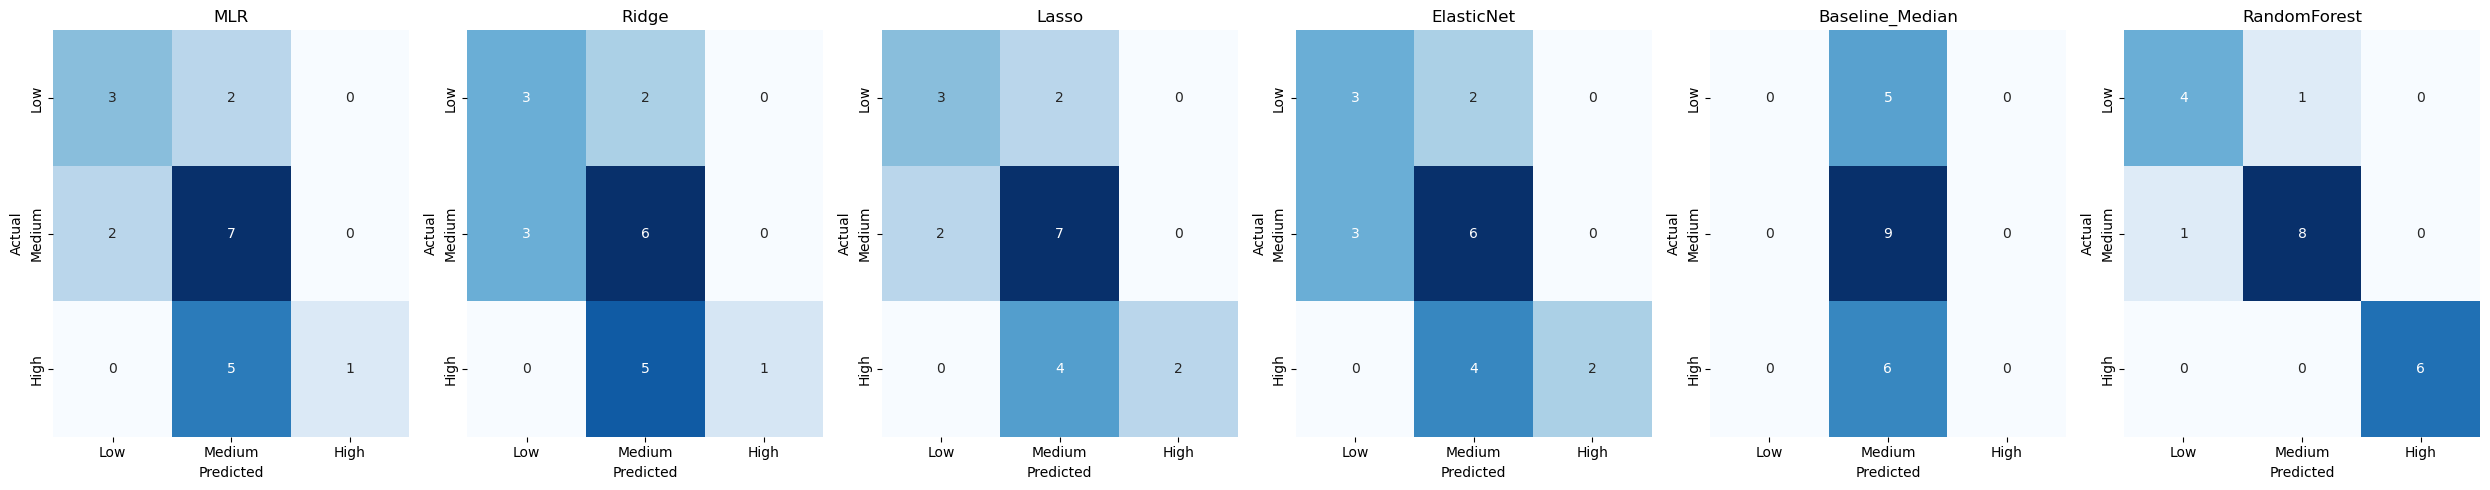

In [33]:
#Chart showing the case tier prediction
fig, axes = plt.subplots(1, 6, figsize=(25, 5))

for ax, (name, pipe) in zip(axes, pipelines.items()):
    preds_log = pipe.predict(X_test)

    # Convert predictions back to actual malaria case counts
    preds_raw = np.expm1(preds_log)

    pred_tiers = to_tier(preds_raw, q1, q3)
    cm = confusion_matrix(y_test_tiers, pred_tiers, labels=['Low', 'Medium', 'High'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'],
                ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../figures/confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

Final Methodology:

We initially modeled the raw malaria case counts, but the target was extremely right-skewed, with a small number of countries having exceptionally high case counts, resulting in poor raw-scale cross-validation performance. We therefore applied a log1p transformation, which compressed the extreme values and allowed the regression models to capture the underlying variation more effectively. The log-scale cross-validation R² values were around 0.50, compared with near-zero or negative values on the raw scale. We then inverse-transformed the predictions back to case counts for interpretation and tier classification. We acknowledge that exact case-count prediction remains limited, particularly for extreme cases, and identify the availability of additional relevant and consistently reported cross-country predictors as an area for future improvement.


For slides:
The target had extreme skewness → raw modeling performed poorly → transformation addressed the statistical problem → performance improved → we transparently retained the raw-scale limitation.

## 11. Variable Significance in prediction

The following snippets explain which variables have the most statistical significance.

In [ ]:
import statsmodels.api as sm

# Build a SEPARATE preprocessor just for this inference analysis —
# uses drop='first' to avoid the dummy variable trap (multicollinearity with the intercept).
# We do NOT touch the original `preprocessor` used by our prediction pipelines,
# since handle_unknown='ignore' without dropping is fine for prediction, just not for OLS inference.
ols_preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

X_processed_full = ols_preprocessor.fit_transform(X)
feature_names_full = ols_preprocessor.get_feature_names_out()

# Add intercept term (statsmodels doesn't add this automatically)
X_with_const = sm.add_constant(X_processed_full)
const_feature_names = ['const'] + list(feature_names_full)

# Fit OLS on the log-transformed target, consistent with our modeling approach elsewhere
ols_model = sm.OLS(y, X_with_const)
ols_results = ols_model.fit()

print(ols_results.summary())

                             OLS Regression Results                             
Dep. Variable:     Median_Malaria_Cases   R-squared:                       0.698
Model:                              OLS   Adj. R-squared:                  0.660
Method:                   Least Squares   F-statistic:                     18.27
Date:                  Thu, 10 Sep 2026   Prob (F-statistic):           3.00e-18
Time:                          14:29:41   Log-Likelihood:                -234.19
No. Observations:                    99   AIC:                             492.4
Df Residuals:                        87   BIC:                             523.5
Df Model:                            11                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.1506      0.559

The findings above show:
1.  x3 (likely Region_Code_EUR, coef = -7.23, p < 0.001) — strongest effect in the whole model. Being in the EUR region is associated with dramatically lower log-case-counts vs. the reference region.

2.  x9 (Median_Sanitation_Access_pct, coef = -2.17, p < 0.001) —  More sanitation access → fewer cases. This one survived the fix and remains our clearest, most defensible significant predictor.

Only region (specifically, being in the EUR region) and sanitation access show a statistically significant, independent relationship with malaria case counts. The climate variables (rainfall, temperature) and the other socioeconomic variables (GDP, urbanization, population density) do not show statistically significant standalone effects once region and sanitation are already accounted for.

In [ ]:
significance_table = pd.DataFrame({
    'Feature': const_feature_names,
    'Coefficient': ols_results.params.values,
    'Std_Error': ols_results.bse.values,
    'p_value': ols_results.pvalues.values,
    'Significant_at_0.05': ols_results.pvalues.values < 0.05
})

significance_table = significance_table[significance_table['Feature'] != 'const']
significance_table = significance_table.sort_values('p_value')
significance_table

,Feature,Coefficient,Std_Error,p_value,Significant_at_0.05
3,cat__Region_Code_EUR,-7.228722,1.482949,0.000005,True
9,num__Median_Sanitation_Access_pct,-2.173789,0.527800,0.000087,True
4,cat__Region_Code_SEAR,-2.711340,1.382917,0.053126,False
1,cat__Region_Code_AMR,-1.992175,1.021856,0.054449,False
7,num__Median_Population_Density,0.338631,0.304311,0.268867,False
10,num__Median_Rainfall,-0.359713,0.331319,0.280610,False
6,num__Median_GDP,-0.285606,0.383331,0.458241,False
5,cat__Region_Code_WPR,-0.826108,1.155591,0.476598,False
2,cat__Region_Code_EMR,-0.278733,1.182797,0.814254,False
11,num__Median_Temp,0.056435,0.343826,0.870002,False


A. Significant (p<0.05)

 Region_Code_EUR (coef -7.23, p < 0.001) — being in Europe is associated with dramatically lower malaria cases compared to Africa (the reference region). Makes strong real-world sense — Europe has minimal endemic malaria.

 Median_Sanitation_Access_pct (coef -2.17, p < 0.001) — more sanitation access is associated with fewer cases, independent of region. This is your strongest non-regional finding.

B. Marginal (0.05 < p < 0.06 — worth mentioning as "approaching significance"):

    Region_Code_SEAR (coef -2.71, p = 0.053)
    Region_Code_AMR (coef -1.99, p = 0.054)

C. Not significant:

    Region_Code_WPR, Region_Code_EMR
    Median_Population_Density, Median_Rainfall, Median_GDP, Median_Temp, Median_Urban_pct

Once controlling for all seven predictors simultaneously, only region (specifically the EUR-vs-AFR contrast) and sanitation access show statistically significant independent effects on log-transformed malaria case counts. Two other regions (SEAR, AMR) show borderline/marginal effects relative to AFR. None of the numeric climate or socioeconomic variables — GDP, population density, urbanization, rainfall, temperature — reach significance once region and sanitation are already in the model.

## 12. Influence /Importance in Prediction
The following snippets show which variables have the greatest impact on prediction.(To my team reading this that may be confused, this section answers Research Question 4 in our paper while the previous section answers Research Question 1, which are 2 different questions).



Across all five models, Median_Sanitation_Access_pct and regional classification (particularly Region_Code_EUR) are the most influential predictors of malaria case counts. Sanitation access shows the most consistent influence across every model type, linear and non-linear alike — making it arguably your single most robust finding across the entire study (it's significant in RQ1, top-ranked in every model's RQ4 comparison, and never zeroed out even by Lasso's aggressive selection). Region matters most in the linear models specifically, while GDP and climate variables show modest, mostly non-significant linear effects but somewhat more presence in the non-linear Random Forest model.(Random Forest is put here only for reference).

In [ ]:
# Fresh models for RQ4 interpretation — same clean encoding as RQ1 (drop='first')
# Kept separate from the deployed `pipelines` dict, which stays untouched for prediction/Streamlit use

from sklearn.ensemble import RandomForestRegressor

rq4_preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first'), categorical_cols),
    ('num', StandardScaler(), numeric_cols)
])

rq4_models = {
    'MLR': LinearRegression(),
    'Ridge': RidgeCV(alphas=alphas_wide, cv=5),
    'Lasso': LassoCV(alphas=alphas_wide, cv=5, random_state=RANDOM_STATE, max_iter=10000),
    'ElasticNet': ElasticNetCV(alphas=alphas_wide, cv=5, random_state=RANDOM_STATE, max_iter=10000),
    'RandomForest': RandomForestRegressor(random_state=RANDOM_STATE)
}

rq4_pipelines = {}
for name, model in rq4_models.items():
    pipe = Pipeline([
        ('preprocessor', rq4_preprocessor),
        ('regressor', model)
    ])
    pipe.fit(X, y)  # full dataset, consistent with RQ1's inference-focused approach
    rq4_pipelines[name] = pipe

print("RQ4 models fitted:", list(rq4_pipelines.keys()))

RQ4 models fitted: ['MLR', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForest']


In [ ]:
# Build the coefficient comparison table
feature_names_rq4 = rq4_pipelines['MLR'].named_steps['preprocessor'].get_feature_names_out()

coef_table = pd.DataFrame(index=feature_names_rq4)

for name in ['MLR', 'Ridge', 'Lasso', 'ElasticNet']:
    coef_table[name] = rq4_pipelines[name].named_steps['regressor'].coef_

# Random Forest importance kept in its own column — different scale (always positive, sums to 1)
coef_table['RandomForest_Importance'] = rq4_pipelines['RandomForest'].named_steps['regressor'].feature_importances_

coef_table.round(4)

,MLR,Ridge,Lasso,ElasticNet,RandomForest_Importance
cat__Region_Code_AMR,-1.9922,-1.8549,-0.0000,-1.3157,0.0054
cat__Region_Code_EMR,-0.2787,-0.1831,0.0000,0.0695,0.0057
cat__Region_Code_EUR,-7.2287,-6.9378,-4.0702,-5.8540,0.1058
cat__Region_Code_SEAR,-2.7113,-2.5448,-0.0000,-1.8666,0.0021
cat__Region_Code_WPR,-0.8261,-0.7144,0.0000,-0.2617,0.0057
num__Median_GDP,-0.2856,-0.2759,-0.0000,-0.2278,0.0857
num__Median_Population_Density,0.3386,0.3386,0.1364,0.3220,0.0487
num__Median_Urban_pct,0.0637,0.0779,0.0000,0.1117,0.0491
num__Median_Sanitation_Access_pct,-2.1738,-2.2420,-2.9407,-2.4916,0.5901
num__Median_Rainfall,-0.3597,-0.3573,-0.3335,-0.3571,0.0498


In [ ]:
# Rank by average absolute impact across the 4 linear models
linear_cols = ['MLR', 'Ridge', 'Lasso', 'ElasticNet']
coef_table['Mean_Abs_Coef'] = coef_table[linear_cols].abs().mean(axis=1)

feature_ranking = coef_table.sort_values('Mean_Abs_Coef', ascending=False)
feature_ranking

,MLR,Ridge,Lasso,ElasticNet,RandomForest_Importance,Mean_Abs_Coef
cat__Region_Code_EUR,-7.228722,-6.937822,-4.070198,-5.854030,0.105831,6.022693
num__Median_Sanitation_Access_pct,-2.173789,-2.241996,-2.940671,-2.491610,0.590078,2.462016
cat__Region_Code_SEAR,-2.711340,-2.544794,-0.000000,-1.866612,0.002106,1.780687
cat__Region_Code_AMR,-1.992175,-1.854913,-0.000000,-1.315687,0.005417,1.290694
cat__Region_Code_WPR,-0.826108,-0.714445,0.000000,-0.261735,0.005685,0.450572
num__Median_Rainfall,-0.359713,-0.357269,-0.333512,-0.357126,0.049764,0.351905
num__Median_Population_Density,0.338631,0.338563,0.136395,0.321976,0.048709,0.283891
num__Median_GDP,-0.285606,-0.275891,-0.000000,-0.227835,0.085659,0.197333
cat__Region_Code_EMR,-0.278733,-0.183145,0.000000,0.069521,0.005667,0.132850
num__Median_Temp,0.056435,0.073721,0.171388,0.135329,0.051977,0.109218


### Testing Documentation (Lucero)

In [ ]:
#Shows real tiers # Build a simple reference table: each country + its actual case count + actual tier
country_tier_reference = pd.DataFrame({
    'Nation': df['Nation'],
    'Country_Code': df['Country_Code'],
    'Actual_Median_Malaria_Cases': y_raw,
    'Actual_Tier': to_tier(y_raw, q1, q3)
})

country_tier_reference = country_tier_reference.sort_values('Actual_Median_Malaria_Cases', ascending=False).reset_index(drop=True)
country_tier_reference

,Nation,Country_Code,Actual_Median_Malaria_Cases,Actual_Tier
0,Democratic Republic of the Congo,COD,21639579.0,High
1,Nigeria,NGA,19066077.5,High
2,Uganda,UGA,13355300.5,High
3,Mozambique,MOZ,10811578.5,High
4,Burkina Faso,BFA,10536320.0,High
...,...,...,...,...
94,Armenia,ARM,2.0,Low
95,Azerbaijan,AZE,1.0,Low
96,Kyrgyzstan,KGZ,1.0,Low
97,Turkmenistan,TKM,0.0,Low


,80/20 Split R² (Raw),80/20 Split R² (Log),CV Mean R² (Raw),CV Mean R² (Log),CV RMSE (Log),CV MAE (Log)
Model,,,,,,
MLR,-0.0303,0.6353,-0.0200,0.5108,2.9405,2.2686
Ridge,-0.1129,0.4759,0.0015,0.5286,2.9366,2.3407
Lasso,-0.0545,0.5975,-0.0523,0.4961,3.0044,2.3995
ElasticNet,-0.0596,0.5664,-0.0018,0.5361,2.9305,2.3503
Baseline,-0.2274,-0.0010,-0.2617,-0.0810,4.7002,3.9539
Random Forest,0.2650,0.6068,0.2222,0.5956,2.8155,2.2237
